## Build the Internal things 

In [1]:
import warnings
warnings.filterwarnings('ignore') 
# PDF fetch 
from langchain_community.document_loaders import PyPDFLoader 
try:
    loader  = PyPDFLoader('Why_Language_Models_Hallucinate_Explainer.pdf')
    pages = loader.load()
except Exception as e :
    print(str(e))
    
# Split the given document 
from langchain_text_splitters import RecursiveCharacterTextSplitter 
text_spliter = RecursiveCharacterTextSplitter(chunk_size=1200 , chunk_overlap=180)
texts = text_spliter.split_documents(pages)

chunks=[i.page_content for  i in texts]
metadata = [i.metadata for i in texts]

import hashlib 
ids=[hashlib.md5(chunk.encode('utf-8')).hexdigest() for chunk in chunks]


In [2]:
# VectorDB create 
import chromadb
from chromadb.utils.embedding_functions import DefaultEmbeddingFunction 
embedding_function = DefaultEmbeddingFunction()

client = chromadb.PersistentClient(path="./VectorDB")

collection = client.get_or_create_collection(name="System",embedding_function=embedding_function)

if collection.count()!=len(chunks):
    collection.upsert(
        documents=chunks,
        ids=ids , 
        metadatas=metadata
    )
collection.count()

21

In [3]:
# Hybrid connection
from rank_bm25 import BM25Okapi 
token_corpus = [i.split() for i in chunks]
tokens = BM25Okapi(token_corpus)
tokens

In [4]:
# Langgraph State Building 
from langgraph.graph import StateGraph , START 
from typing import Annotated ,TypedDict 
from langgraph.graph.message import add_messages

class State(TypedDict):
    messages:Annotated[list,add_messages]
    
# LLM connection 
from langchain_groq import ChatGroq 
import os 
from dotenv import load_dotenv 
load_dotenv()
os.getenv('GROQ_API_KEY')
LLM = ChatGroq(model='openai/gpt-oss-120b')
response = LLM.invoke('hello')
response.content

'Hello! How can I help you today?'

In [5]:
# Hybrid Retrival 
from langchain_core.messages import AIMessage
def Hybrid_Rag(state:State):   
    query = state['messages'][-1].content
    prompt = f""" 
    write the query based on only for symentic and keyword search :
    {query} """
    query_rewrite = LLM.invoke(prompt).content
    
    result = collection.query(query_texts=[query_rewrite] , n_results=3)
    distances = result['distances'][0]
    documents = result['documents'][0]
    print(distances)
    threshold = 1.5
    dense_chunks = []
    for dis , doc in zip(distances,documents):
        if threshold > dis :
            dense_chunks.append(doc)
        # Keyword search connection
    scores = tokens.get_scores(query_rewrite.split())
    def get_keywords(scores,k=10):
        index = list(enumerate(scores))
        sorted_index = sorted(index , key = lambda x:x[1] , reverse=True)
        return [doc for doc , i in sorted_index[:k]]
    keywords=get_keywords(scores=scores , k=10)
    get_docs=[chunks[i]for i in keywords]
    
    rrf_tokens={}
    for rank , doc in enumerate(dense_chunks):
        rrf_tokens[doc] = rrf_tokens.get(doc,0)+1/(rank+60)
    for rank,doc in enumerate(get_docs):
        rrf_tokens[doc] = rrf_tokens.get(doc,0)+1/(rank+60)
    
    marge = sorted(rrf_tokens.items(),key=lambda x:x[1] , reverse=True)
    top_docs = [i for i , x in marge[:5]]
    
    return {
    "messages": [
        AIMessage(content=f"""
Use this retrieved context to answer the user's question:


User question:
{query}
""")
    ],
    "retrieved_context": top_docs
}

In [6]:
# Tool creation 
from langchain_core.tools import tool 
from langchain_community.tools import DuckDuckGoSearchRun
import requests 
import numexpr 
# calculator 
@tool 
def calculator(execution:str):
    """ 
    Do all the user provided arithmetic calculation by this tool 
    """
    try:
        result = numexpr.evaluate(execution)
        return str(result)
    except Exception as e :
        return str(e)
#weather   
@tool 
def weather(location:str):
    """
    Fetch the user provided location's Weather
    """
    try:
        response = requests.get(url=f"https://wttr.in/{location}?format=3").text
        return response 
    except Exception as e :
        return str(e)
# websearch 
@tool 
def web_search(query:str):
    """If retrival fails to give data use this tool"""
    try:
        search  = DuckDuckGoSearchRun()
        return search.run(query)
    except Exception as e :
        return str(e)
    
import os

@tool
def file_handler(operation: str, file_path: str, content: str = ""):
    """
    Handles basic file operations such as create, read, append, and delete.
    """

    if operation == "create":
        with open(file_path, "w") as file:
            file.write(content)
        return f"File created: {file_path}"

    elif operation == "read":
        with open(file_path, "r") as file:
            return file.read()

    elif operation == "append":
        with open(file_path, "a") as file:
            file.write(content)
        return f"Content added to: {file_path}"

    elif operation == "delete":
        if os.path.exists(file_path):
            os.remove(file_path)
            return f"File deleted: {file_path}"
        return "File not found."

    else:
        return "Invalid operation."

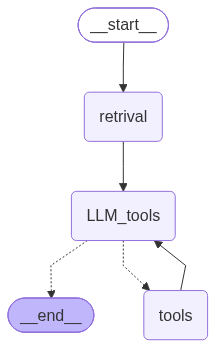

In [7]:
#tool blind 
tools=[weather,calculator,web_search,file_handler]
LLM_tool=LLM.bind_tools(tools)

from langgraph.checkpoint import memory 
memory = memory.MemorySaver()

# connection 
def tool_connection(state:State):
    response = LLM_tool.invoke(state['messages'])
    return {'messages':response}

# connection state 
Graph = StateGraph(State)
from langgraph.prebuilt import tools_condition , ToolNode 

# Edge builder
Graph.add_node('retrival',Hybrid_Rag)
Graph.add_node('LLM_tools',tool_connection)
Graph.add_node('tools',ToolNode(tools))

# Building node 
Graph.add_edge(START,'retrival')
Graph.add_edge('retrival','LLM_tools')
Graph.add_conditional_edges(
    'LLM_tools',
    tools_condition ,
    {"tools": "tools", "__end__": "__end__"},   
)
Graph.add_edge('tools','LLM_tools')

config = {'configurable':
    {"thread_id": "user_1"}
    }

connention = Graph.compile(memory)
connention

In [8]:
from langchain_core.messages import HumanMessage

question = "what is full form of llm?"
for chunk in connention.stream(
    {
        "messages": [
            HumanMessage(content=question)
        ]
    },
    config=config
):
    print(chunk)

[1.3939297199249268, 1.5135382413864136, 1.5135384798049927]
{'retrival': {'messages': [AIMessage(content="\nUse this retrieved context to answer the user's question:\n\n\nUser question:\nwhat is full form of llm?\n", additional_kwargs={}, response_metadata={}, id='2da04809-29f1-477e-9052-84d1da56b52b', tool_calls=[], invalid_tool_calls=[])]}}
{'LLM_tools': {'messages': AIMessage(content='The abbreviation **LLM** commonly stands for **“Large Language Model.”**  \n\nIn the context of artificial intelligence, a large language model is a type of neural network trained on massive text datasets to understand and generate human‑like language (e.g., GPT‑4, Claude, LLaMA).  \n\n*(Note: In academia, “LL.M.” can also mean “Master of Laws,” but in AI discussions it refers to “Large Language Model.”)*', additional_kwargs={'reasoning_content': 'The user asks: "what is full form of llm?" They likely refer to "LLM" in AI context: "Large Language Model". Could also be "Master of Laws" (LL.M.) but cont

In [9]:
from langchain_core.messages import HumanMessage
response=connention.invoke({'messages':[HumanMessage(content="what is the current weather in kolkata and situation?")]},config=config)
result = response['messages'][-1].content
result

[1.5412893295288086, 1.629969596862793, 1.629969835281372]


'**Current Weather in Kolkata (as of the latest update):**  \n- **Condition:** 🌤️ Partly cloudy / mostly sunny  \n- **Temperature:** **28\u202f°C** (≈\u202f82\u202f°F)  \n- **Humidity:** Around 65\u202f% (typical for this time of year)  \n- **Wind:** Light breeze from the southwest at about 8\u202fkm/h (5\u202fmph)  \n\n**General Situation / What to Expect Right Now:**\n\n- **Air Quality:** Kolkata’s air quality is usually moderate during this season. If you’re planning outdoor activities, it’s a good idea to check a real‑time AQI (Air Quality Index) service for any sudden spikes, especially after traffic congestion or construction work.\n- **Traffic:** The city’s traffic can be heavy during peak hours (7\u202f–\u202f10\u202fam and 5\u202f–\u202f8\u202fpm). If you’re traveling by road, allow extra time or consider using public transport (Metro, buses, or ride‑share services) to avoid delays.\n- **Rainfall:** The city is approaching the monsoon period (June‑September). Light showers can

## DataBase creation 

In [10]:
from sqlalchemy import Integer , Column , String , create_engine 
from sqlalchemy.orm import DeclarativeBase , sessionmaker 

# Create URL 
DATABASE_URL="sqlite:///.SQL_DataBase.db"

# Create engine 
engine = create_engine(url=DATABASE_URL , connect_args={'check_same_thread':False})

# declare base 
class base(DeclarativeBase):
    pass
# session create 
session = sessionmaker(bind=engine , autoflush=False , autocommit=False)

# Create DB 
class QueryHistory(base):
    __tablename__ = "Database_FAST"
    user_id = Column(Integer , autoincrement=True , primary_key=True)
    question = Column(String)
    limit = Column(Integer)
    answer = Column(String)
base.metadata.create_all(bind=engine)

def create_db():
    db = session()
    try: 
        yield db 
    finally : 
        db.close()

# Fast API connection 

In [11]:
from fastapi import FastAPI ,HTTPException , Depends
from database import QueryHistory , create_db
app = FastAPI(title="api_system")
from pydantic import BaseModel

class QusAns(BaseModel):
    question : str 
    user_id : int = None 
    limit : int = 100 
    
@app.put("/ask")
def update(request:QusAns , db=Depends(create_db)):
    question = db.query(QueryHistory).filter(QueryHistory.user_id == request.user_id).first()
    if not question:
        raise HTTPException(status_code=400 , detail="questions not find out")
    question.question = request.question 
    db.commit()
    db.refresh(question)
    
    return question

@app.get("/ask")
def fetch(db = Depends(create_db)):
    try:
        questions = db.query(QueryHistory).all()
        return [
              {"id": q.id, "question": q.question, "answer": q.answer, "user_id": q.user_id}
              for q in questions
          ]
    except Exception as e:
        raise HTTPException(status_code=400 , detail=str(e))
    
@app.delete("/ask")
def delete(requests:QusAns , db=Depends(create_db)):
    question = db.query(QueryHistory).filter(QueryHistory.user_id == requests.user_id).first()
    
    if not question:
        raise HTTPException(status_code=400 , detail="no valid question")
    delete = question.id
    db.delete(question)
    db.commit()
    
    return {
        'status':'deleted',
        'delete':delete
    }
    

@app.post("/chat")
def Question_Answer(request:QusAns , db=Depends(create_db)):
    try:
        result = connention.invoke({
            'messages':
                [HumanMessage(content=request.question)]
        })
        answer = result['messages'][-1].content

        db_question = QueryHistory(
            question = request.question , 
            user_id = request.user_id , 
            limit = request.limit , 
            answer = answer
        )

        db.add(db_question)
        db.commit()
        db.refresh(db_question)
        
        return {
            
            'question':db_question.question,
            'limit':db_question.limit,
            'id': db_question.id , 
            'answer':answer
        }
    except Exception as e :
        raise HTTPException(status_code=400 , detail=str(e))

## Evelution 

In [12]:
from langchain_ollama import ChatOllama 
from langchain_core.messages import HumanMessage

LLM = ChatOllama(model='qwen2.5:1.5b')
import nest_asyncio
nest_asyncio.apply()
from ragas.metrics import context_precision , context_recall , answer_relevancy , faithfulness 
from datasets import Dataset 
from ragas import evaluate 

def generate_answer(question:str , context_list:list):
    if not context_list:
        return "Not related content"
    content_str = "\n\n".join(context_list)
    prompt = f"""
    You are a reliable and helpful assistent so provided every qustion answers based on Local document 
    
    context str : {content_str}
    question : {question}
    """
    return LLM.invoke(prompt).content
question = "What is hallucination in language models?"
ground_truth = "The tendency of large language models to produce fluent, confident, and factually wrong statements."

retrive = Hybrid_Rag(
    {'messages': [HumanMessage(content=question)]}
)

retrieved_context = retrive["retrieved_context"]

answer = generate_answer(
    question=question,
    context_list=retrieved_context
)
answer = generate_answer(question=question , context_list=retrive)

data = {
    "user_input": [question],
    "response": [answer],
    "retrieved_contexts": [retrieved_context],
    "reference": [ground_truth]
}

dataset = Dataset.from_dict(data)
from langchain_huggingface.embeddings import HuggingFaceEmbeddings
embedding = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")

result = evaluate(
    dataset=dataset , 
    metrics=[
        faithfulness,
        context_precision,
        answer_relevancy,
        context_recall
    ]
    , 
    llm=LLM , 
    embeddings=embedding
)

print(result)

[0.9152168035507202, 0.9152171611785889, 0.9525429606437683]


Evaluating: 100%|██████████| 4/4 [01:37<00:00, 24.39s/it]

{'faithfulness': 1.0000, 'context_precision': 1.0000, 'answer_relevancy': nan, 'context_recall': 1.0000}


In [13]:
import sys
print(sys.executable)
print(sys.version)

/Users/debajyotihazra/Documents/MultiTool Agent System/.venv/bin/python
3.14.0 (main, Nov 19 2025, 23:04:28) [Clang 21.1.4 ]


In [14]:
print("QUESTION:", question)
print("ANSWER:", answer)
print("CONTEXT:", retrieved_context)
print("GROUND TRUTH:", ground_truth)

QUESTION: What is hallucination in language models?
ANSWER: Hallucination refers to the situation where a language model produces a response that contains inaccurate or nonsensical information. This type of error can occur due to several factors, including the limitations of the language model's training data, the model's ability to generalize knowledge, and the randomness of the model's output generation process.

When a language model hallucinates, it generates an answer that appears to be plausible but is actually incorrect or irrelevant. This can happen for various reasons, such as the model's inability to process the context properly, the absence of relevant information in its training data, or the influence of external noise or biases in the input data.

Hallucinations can be frustrating for language model users, as they may lead to misunderstandings or even miscommunication. To mitigate the occurrence of hallucinations, researchers and developers are continually working on impro